# 선형회귀 직접 구현

## 데이터셋 준비

 - 사이킷런 임의 회귀 데이터 생성

In [1]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

In [2]:
# 가상의 데이터 생성
data = make_regression(n_samples = 1000, n_features = 1, bias = 1000, noise = 50) 
# 1000개의 데이터, 1개의 특성 가진 데이터 셋을 생성합니다.

#X_1 -> data[0] / y_1 -> data[1]

In [3]:
x_train = data[0]
y_train = data[1]

n_data = len(x_train)
print(n_data, x_train.shape, y_train.shape)

1000 (1000, 1) (1000,)


## Hypothesis, Cost 정의

 - hypothesis: x_train * w1 + w0
 - cost : RSS (Residual Sum of Squares) -> MSE

## Weight 초기화

In [4]:
w1 = np.random.rand(1)
w0 = np.random.rand(1)
print(w1, w0)

[0.65976141] [0.07364633]


## y_pred 계산

In [ ]:
# x_train @ w1

In [8]:
y_pred = w1 * x_train + w0
y_pred.shape

(1000, 1)

In [10]:
y_train.shape

(1000,)

## cost 계산

 - cost = np.sum((y_train - y_pred) ** 2) / n_data

In [42]:
shape = (y_train - y_pred).shape # 브로드캐스팅으로 인해서 데이터 개수가 뻥튀기된다. (잘못 계산됨)
print(shape)
np.sum((y_train - y_pred)**2)/n_data  # 오차 뻥튀기 됨

(1000, 1000)


np.float64(1006097524.6783123)

In [22]:
(y_train - y_pred.ravel()).shape

(1000,)

In [ ]:
np.sum((y_train - y_pred.ravel()) ** 2) / n_data

np.float64(1006088.2824188228)

## Weight 업데이트

 - w1 = (-1) * np.sum((y_train - y_pred)  * x_train) * 2 / n_data
 - w0 = (-1) * np.sum(y_train - y_pred) * 2 / n_data

In [49]:
y_train[0], y_pred[0], x_train[0]

(np.float64(910.6061602435994), array([-0.02652331]), array([-0.15182708]))

In [55]:
dw1 = 0
for i in range(1000):
    dw1 += (y_pred[i] - y_train[i]) * x_train[i] * 2

dw1 / n_data

array([16.03425392])

In [ ]:
w1 = w1 - 2 * (y_pred.ravel() - y_train) @ x_train / n_data  # 1000, 1

array([16.03425392])

In [ ]:
# 브로드캐스팅 문제 (1000, ) * (1000, 1) => (1000, 1000) 의도치 않은 결과
2 * (y_pred.ravel() - y_train) * x_train

array([[  276.51739595,   297.5459628 ,   280.35729843, ...,
          298.77022654,   304.78009307,   312.81583222],
       [ 4768.78074429,  5131.43649801,  4835.00317097, ...,
         5152.54998103,  5256.19530751,  5394.77855294],
       [-1001.21979693, -1077.36045837, -1015.12339371, ...,
        -1081.79329735, -1103.553944  , -1132.64991135],
       ...,
       [ 2712.17285414,  2918.4278999 ,  2749.83587066, ...,
         2930.43587816,  2989.38261025,  3068.19976215],
       [ 1686.9889082 ,  1815.28086937,  1710.41554601, ...,
         1822.74990885,  1859.41515423,  1908.43992816],
       [-4980.74512902, -5359.52032875, -5049.9110326 , ...,
        -5381.57227103, -5489.82446015, -5634.5675007 ]],
      shape=(1000, 1000))

In [ ]:
w0 = w0 - 2 * np.mean((y_pred.ravel() - y_train))

## 반복

 - epochs : 반복횟수
 - learning rate : 학습률

 - 출력 지우기
    - from IPython.display import clear_output 
    - clear_output()

In [57]:
epochs = 1000
learning_rate = 0.01

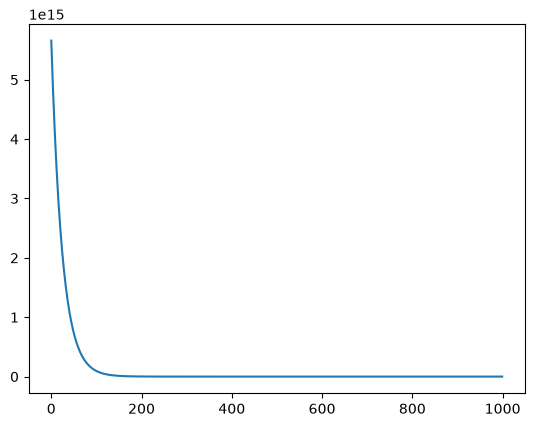

In [ ]:
history = {
    'cost': []
}

for epoch in range(epochs):
    # 1. y_pred 계산
    y_pred = w1 * x_train + w0

    # 2. cost 계산
    cost = np.sum((y_train - y_pred.ravel()) ** 2) / n_data
    history['cost'].append(cost)

    # 3. 가중치 업데이트
    dw1 = 2 * (y_pred.ravel() - y_train) @ x_train / n_data 
    dw0 = 2 * np.mean((y_pred.ravel() - y_train))
    w1 = w1 - learning_rate * dw1
    w0 = w0 - learning_rate * dw0

plt.plot(history['cost'])

In [ ]:
X, y = make_regression(n_samples=1000, n_features=100)

In [ ]:
weights = np.random.random(100)
bias = np.random.random(1)

In [68]:
X.shape

(1000, 100)

In [67]:
weights.shape

(100,)

In [73]:
y_pred = X @ weights + bias

In [ ]:
# Cost에 대해서 w1부터 w100까지 편미분?
# => 규칙을 찾는다.